# Hydrogen molecule using Gausslet orbitals and the full ERI tensor

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

from hydrogen_molecule_eri import hydrogen_molecule_groundstate_gausslets_eri

In [2]:
# Gausslet G10 coefficients
import sys
sys.path.append("../gausslets/")
from gausslets import get_gausslet_g10_coeffs
gausslet_coeffs, gausslet_indices = get_gausslet_g10_coeffs()

In [3]:
# equilibrium nuclear distance of the hydrogen molecule: 74 picometers converted to atomic units
nuclear_dist = 1.4

In [4]:
# list of grid lengths along each coordinate direction
grid_lengths = [3, 5]

In [5]:
# list of grid scaling factors
scaling_list = [i / 20 for i in range(12, 31)]

In [6]:
rng = np.random.default_rng(42)

en0_table  = {}
psi0_table = {}
for d in grid_lengths:
    en0_table[d], psi0_table[d] = \
        hydrogen_molecule_groundstate_gausslets_eri(
            nuclear_dist, gausslet_coeffs, d, scaling_list, tol=1e-5, rng=rng)

In [7]:
# minimal energy for each grid length
{d: min(en0_table[d]) for d in grid_lengths}

{3: -1.0115217436722284, 5: -1.0842034542128083}

In [8]:
# reference ground state energy taken from:
#   James S. Sims, Stanley A. Hagstrom
#   High precision variational calculations for the Born-Oppenheimer energies
#   of the ground state of the hydrogen molecule
#   J. Chem. Phys. 124, 094101 (2006)
#   https://doi.org/10.1063/1.2173250
en0_ref = -1.174475714220

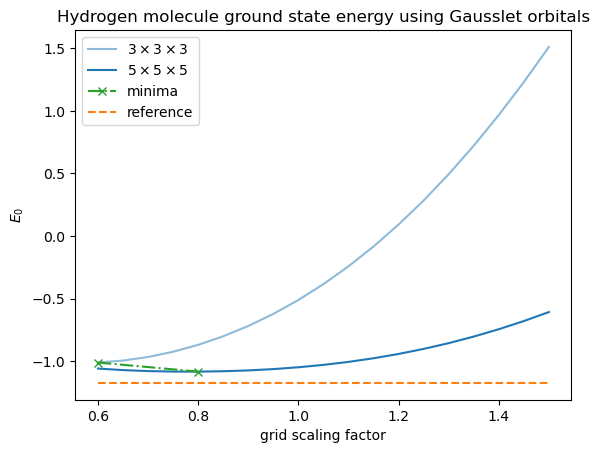

In [9]:
# visualize computed ground state energy in dependence of the scaling factor,
# for various grid dimensions
idx_min = {}
for d in grid_lengths:
    idx_min[d] = int(np.argmin(en0_table[d]))
for i, d in enumerate(grid_lengths):
    plt.plot(scaling_list, en0_table[d], color="tab:blue", alpha=(i+1)/len(grid_lengths),
             label=rf"${d} \times {d} \times {d}$")
plt.plot([scaling_list[idx_min[d]] for d in grid_lengths],
         [en0_table[d][idx_min[d]] for d in grid_lengths], 'x-.',
         color="tab:green", label="minima")
plt.plot(scaling_list, len(scaling_list) * [en0_ref], '--', color="tab:orange", label="reference")
plt.xlabel("grid scaling factor")
plt.ylabel(r"$E_0$")
plt.legend()
plt.title("Hydrogen molecule ground state energy using Gausslet orbitals")
plt.savefig("hydrogen_molecule_eri_energy.pdf")
plt.show()

In [10]:
# check symmetry w.r.t. swapping the first and second particle of the computed wavefunctions
err_symm = 0
for d in grid_lengths:
    for psi0 in psi0_table[d]:
        psi0mat = np.reshape(psi0, 2*(d**3,))
        err_symm = max(err_symm, np.linalg.norm(psi0mat - psi0mat.T))
print("maximum symmetry error:", err_symm)

maximum symmetry error: 7.411015210085497e-15


In [11]:
# save data to disk
with h5py.File("hydrogen_molecule_eri.hdf5", "w") as file:
    file.attrs["nuclear_dist"] = nuclear_dist
    file.attrs["grid_lengths"] = grid_lengths
    file.attrs["scaling_list"] = scaling_list
    for d in grid_lengths:
        file[f"en0_{d}"]  = en0_table[d]
        file[f"psi0_{d}"] = psi0_table[d]